In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.datasets import load_iris
from pathlib import Path
# carregar o dataset maquin3 maquina4 e maquina5


# Transformar CSV (long) em DataFrame (wide)
Esses CSVs estão no formato *long* (colunas: `variable`, `value`, `group`, `time`).
A ideia é transformar `variable` em colunas e usar `group` + `time` como índice (um registro por grupo e instante).

In [51]:
from pathlib import Path
import os

def find_diadema_dir(start: str | Path | None = None) -> Path:
    """Encontra a pasta 'Diadema' subindo a partir do diretório atual (ou 'start')."""
    start_path = Path(start) if start is not None else Path.cwd()
    start_path = start_path.resolve()
    for p in [start_path, *start_path.parents]:
        candidate = p / "Diadema"
        if candidate.exists() and candidate.is_dir():
            return candidate
    raise FileNotFoundError(
        "Não encontrei a pasta 'Diadema' a partir de: "
        + str(start_path)
        + ". Ajuste o start= ou use o caminho absoluto."
    )

def load_and_pivot_csv(path: str | Path) -> pd.DataFrame:
    """
    Lê um CSV no formato long e devolve um DataFrame wide:
    - index lógico: (group, time)
    - colunas: variables
    - values: value (numérico)
    """
    path = Path(path)
    df_long = pd.read_csv(path)

    expected = {"variable", "value", "group", "time"}
    missing = expected - set(df_long.columns)
    if missing:
        raise ValueError(f"CSV {path} está sem colunas esperadas: {sorted(missing)}")

    df_long["time"] = pd.to_datetime(df_long["time"], errors="coerce", utc=True).dt.tz_convert(None)
    df_long["value"] = pd.to_numeric(df_long["value"], errors="coerce")

    # Se houver duplicatas por (group,time,variable), escolhe o último valor (após ordenar por time)
    df_long = df_long.sort_values(["group", "time"])

    df_wide = (
        df_long.pivot_table(
            index=["group", "time"],
            columns="variable",
            values="value",
            aggfunc="last",
        )
        .reset_index()
        .sort_values(["group", "time"])
    )

    # deixa os nomes das colunas simples (sem name='variable')
    df_wide.columns.name = None
    return df_wide

# Base do projeto: tenta achar 'Diadema' automaticamente
diadema_dir = find_diadema_dir()
m3_dir = diadema_dir / "Maquina4"

vel_m3_path = m3_dir / "Velocidade04.csv"
acc_m3_path = m3_dir / "Aceleração04.csv"

df_vel_m3 = load_and_pivot_csv(vel_m3_path)
df_acc_m3 = load_and_pivot_csv(acc_m3_path)



# Colapsar para 1 linha por `group`
Como existem múltiplas linhas por `group` (vários `time` e às vezes variáveis em instantes levemente diferentes), vamos consolidar em uma única linha por `group` pegando o **último valor não-nulo** de cada coluna e descartando grupos incompletos (com `NaN`).

In [52]:
def collapse_to_one_row_per_group(df_wide: pd.DataFrame) -> pd.DataFrame:
    """
    Consolida várias linhas por group em uma única linha:
    - para cada coluna de medida, pega o último valor não-nulo dentro do group
    - descarta groups que ficarem com NaN em qualquer medida
    """
    if "group" not in df_wide.columns:
        raise ValueError("df_wide precisa ter a coluna 'group'")

    # colunas de medidas (tudo menos group/time)
    measure_cols = [c for c in df_wide.columns if c not in {"group"}]

    def last_non_null(s: pd.Series):
        s2 = s.dropna()
        return s2.iloc[-1] if len(s2) else np.nan

    df_group = (
        df_wide.sort_values(["group", "time"])
        .groupby("group", as_index=False)[measure_cols]
        .agg(last_non_null)
    )

    # descarta grupos incompletos
    #df_group = df_group.dropna(subset=measure_cols).reset_index(drop=True)
    return df_group

df_vel_m3_group = collapse_to_one_row_per_group(df_vel_m3)
df_acc_m3_group = collapse_to_one_row_per_group(df_acc_m3)

# Remover segundos e milesimos da coluna time
df_acc_m3_group['time'] = df_acc_m3_group['time'].dt.floor('min')
df_vel_m3_group['time'] = df_vel_m3_group['time'].dt.floor('min')


# ordenar por time
#display(df_vel_m3_group.head())
#display(df_acc_m3_group.head())

df_vel_m3_group = df_vel_m3_group.sort_values(by='time')
df_acc_m3_group = df_acc_m3_group.sort_values(by='time')

# apagar os primeiros 100 dados (mais antigos) para tirar inconsistências
drop_n = 100
df_vel_m3_group = df_vel_m3_group.iloc[drop_n:].reset_index(drop=True)
df_acc_m3_group = df_acc_m3_group.iloc[drop_n:].reset_index(drop=True)

#arrumar as linhas para a primeira ser a data mais velha e a ultima ser a mais nova


#transformar todos os float64 em float16
for col in df_vel_m3_group.select_dtypes(include=['float64']).columns:
    df_vel_m3_group[col] = df_vel_m3_group[col].astype('float32')
for col in df_acc_m3_group.select_dtypes(include=['float64']).columns:
    df_acc_m3_group[col] = df_acc_m3_group[col].astype('float32')

#remover a coluna group
df_vel_m3_group = df_vel_m3_group.drop(columns=['group'])
df_acc_m3_group = df_acc_m3_group.drop(columns=['group'])

display(df_vel_m3_group.head())
display(df_vel_m3_group.info())
display(df_acc_m3_group.head())
display(df_acc_m3_group.info())

,time,maxtemp,maxxpk,maxypk,maxzpk,meanxrms,meanyrms,meanzrms
0,2025-12-11 21:46:00,26.0,40.0,54.0,51.0,13.142858,14.714286,12.142858
1,2025-12-11 21:51:00,26.0,39.0,48.0,54.0,9.857142,14.571428,14.571428
2,2025-12-11 21:56:00,28.0,42.0,51.0,51.0,12.000000,14.571428,15.857142
3,2025-12-11 22:01:00,27.0,43.0,35.0,39.0,12.666667,11.166667,10.166667
4,2025-12-11 22:06:00,29.0,30.0,38.0,92.0,7.090909,8.363636,13.272727


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6585 entries, 0 to 6584
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   time      6585 non-null   datetime64[ns]
 1   maxtemp   6559 non-null   float32       
 2   maxxpk    6585 non-null   float32       
 3   maxypk    6559 non-null   float32       
 4   maxzpk    6559 non-null   float32       
 5   meanxrms  6585 non-null   float32       
 6   meanyrms  6559 non-null   float32       
 7   meanzrms  6559 non-null   float32       
dtypes: datetime64[ns](1), float32(7)
memory usage: 231.6 KB


None

,time,maxtemp,maxxpk,maxypk,maxzpk,meanxrms,meanyrms,meanzrms
0,2025-12-11 21:46:00,28.0,30.0,44.0,78.0,6.916667,8.250000,12.000000
1,2025-12-11 21:51:00,28.0,40.0,44.0,48.0,13.285714,15.000000,14.000000
2,2025-12-11 21:56:00,26.0,39.0,35.0,52.0,13.250000,10.375000,14.500000
3,2025-12-11 22:01:00,26.0,28.0,46.0,60.0,7.000000,8.142858,9.923077
4,2025-12-11 22:06:00,27.0,28.0,42.0,78.0,7.000000,8.333333,11.916667


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6585 entries, 0 to 6584
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   time      6585 non-null   datetime64[ns]
 1   maxtemp   6536 non-null   float32       
 2   maxxpk    6585 non-null   float32       
 3   maxypk    6536 non-null   float32       
 4   maxzpk    6536 non-null   float32       
 5   meanxrms  6585 non-null   float32       
 6   meanyrms  6536 non-null   float32       
 7   meanzrms  6536 non-null   float32       
dtypes: datetime64[ns](1), float32(7)
memory usage: 231.6 KB


None

Text(0.5, 1.0, 'Gráfico das variáveis de Aceleração ao longo do tempo')

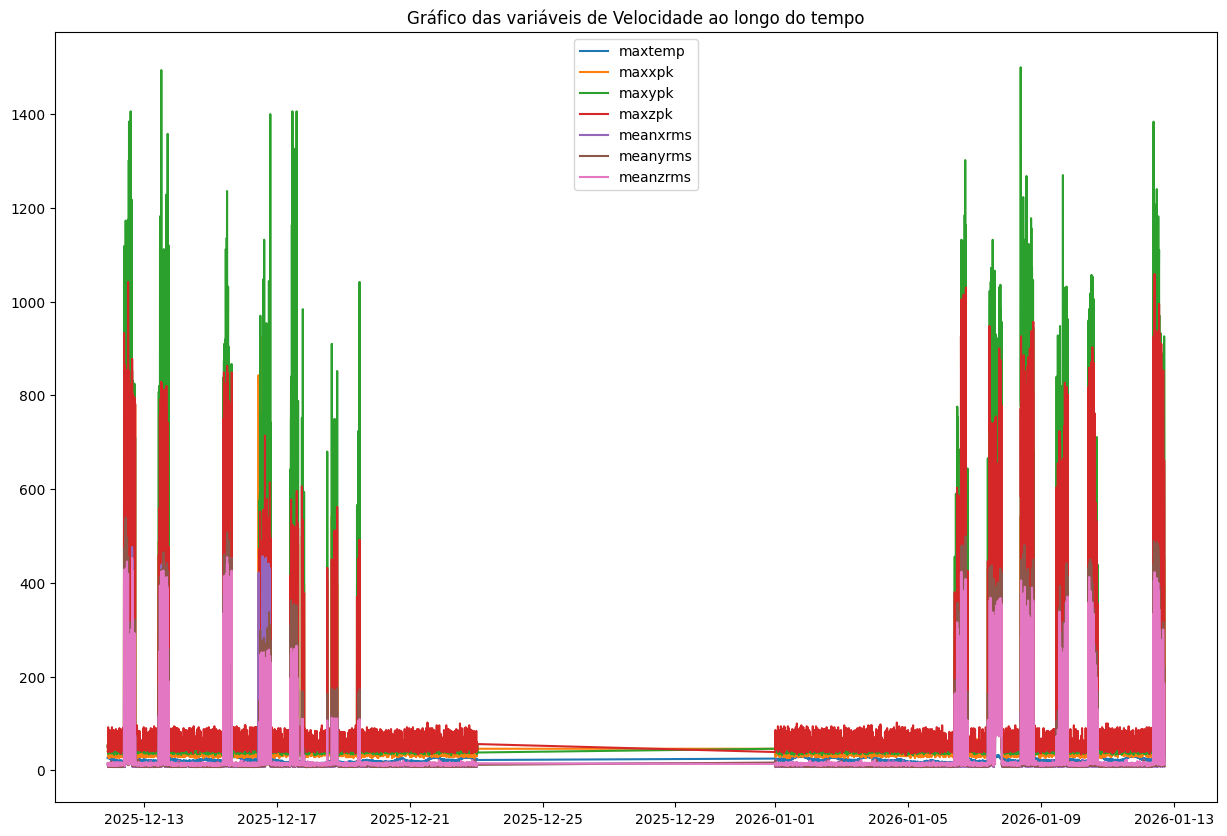

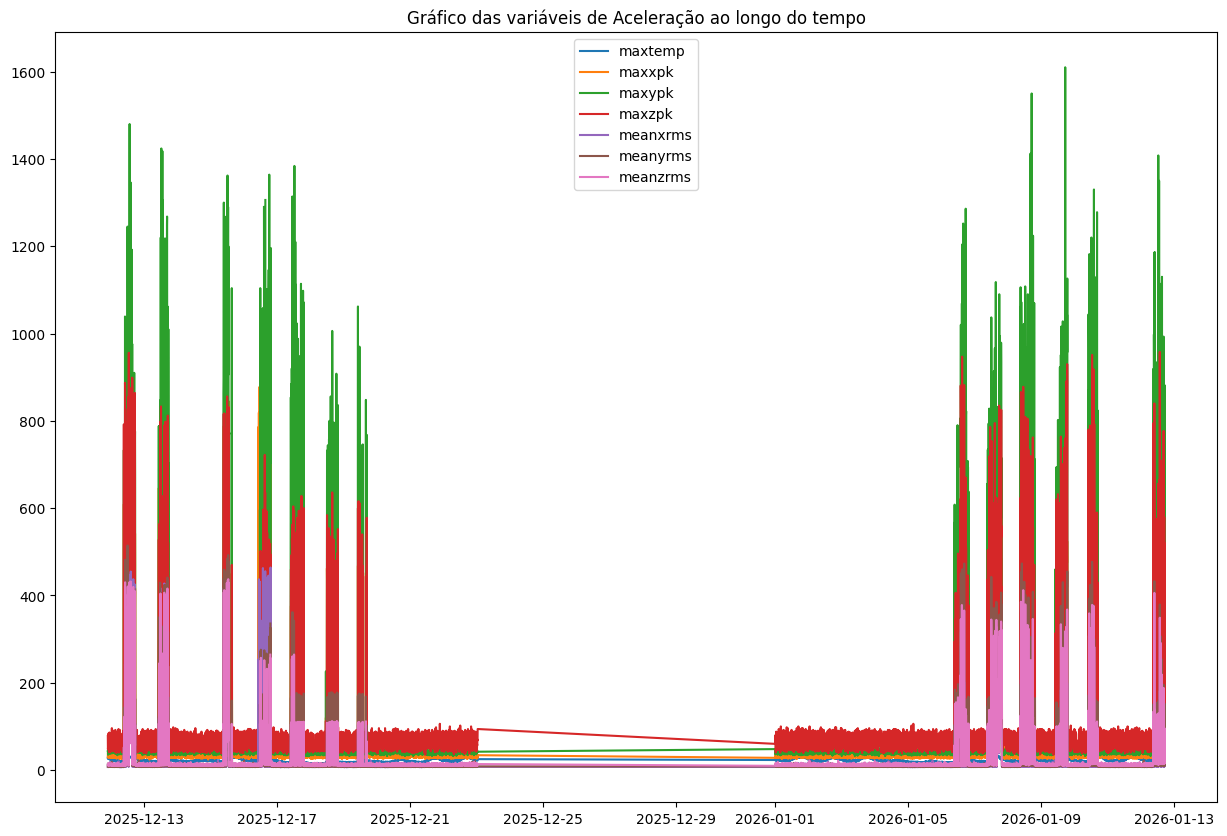

In [53]:
#plotar os graficos das variaveis no tempo
plt.figure(figsize=(15, 10))
for col in df_vel_m3_group.columns:
    if col != 'time':
        plt.plot(df_vel_m3_group['time'], df_vel_m3_group[col], label=col)
plt.legend()
plt.title('Gráfico das variáveis de Velocidade ao longo do tempo')
plt.figure(figsize=(15, 10))
for col in df_acc_m3_group.columns:
    if col != 'time':
        plt.plot(df_acc_m3_group['time'], df_acc_m3_group[col], label=col)
plt.legend()
plt.title('Gráfico das variáveis de Aceleração ao longo do tempo')

Text(0.5, 1.0, 'Gráfico da Temperatura ao longo do tempo')

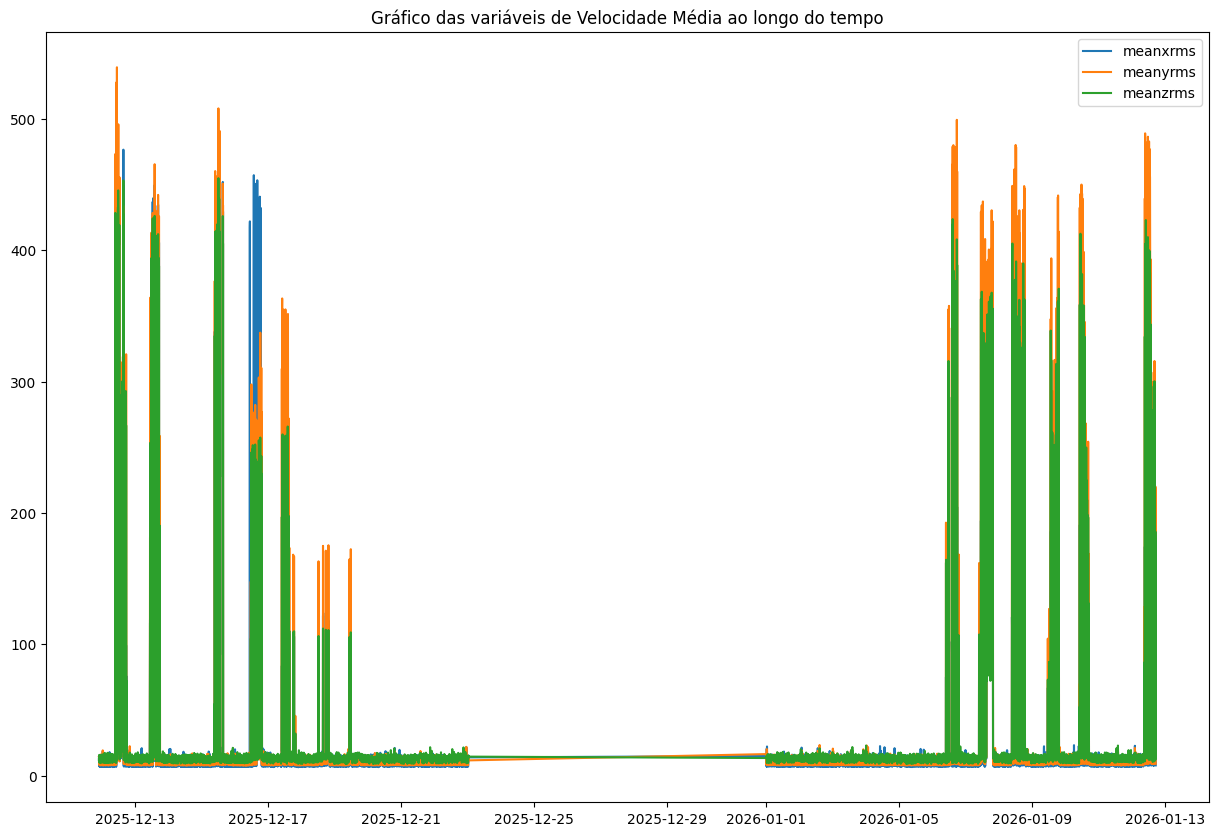

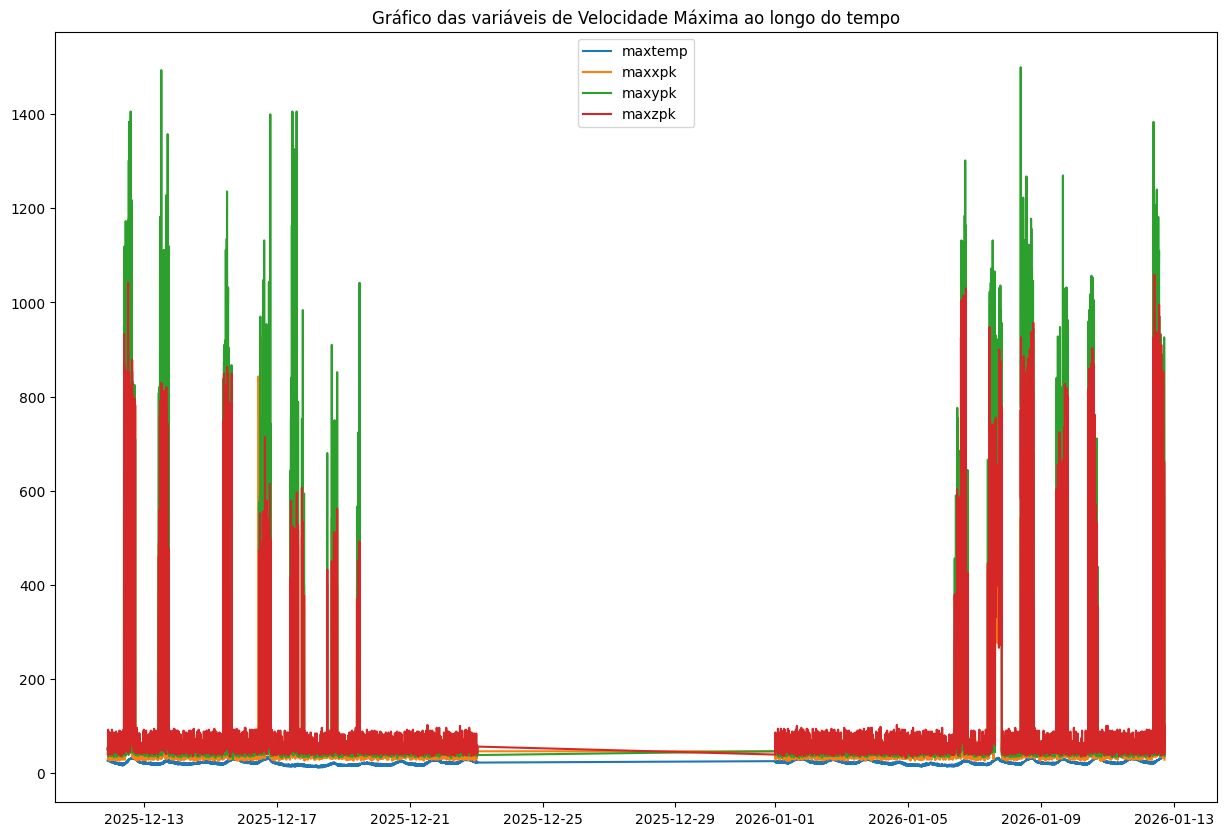

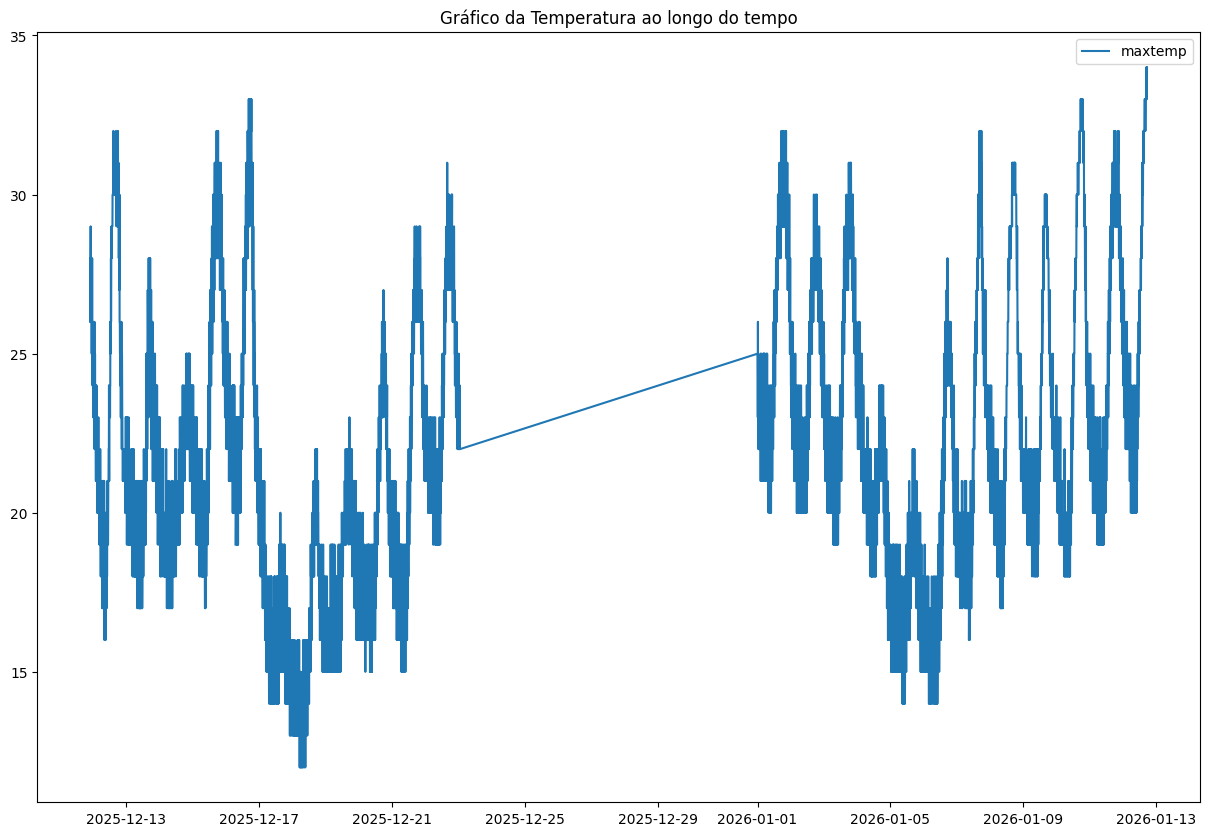

In [54]:
#separar os graficos das médias e das maximas, e tambem o de temperatura
plt.figure(figsize=(15, 10))
for col in df_vel_m3_group.columns:
    if 'mean' in col:
        plt.plot(df_vel_m3_group['time'], df_vel_m3_group[col], label=col)
plt.legend()
plt.title('Gráfico das variáveis de Velocidade Média ao longo do tempo')
plt.figure(figsize=(15, 10))
for col in df_vel_m3_group.columns:
    if 'max' in col:
        plt.plot(df_vel_m3_group['time'], df_vel_m3_group[col], label=col)
plt.legend()
plt.title('Gráfico das variáveis de Velocidade Máxima ao longo do tempo')
plt.figure(figsize=(15, 10))
for col in df_vel_m3_group.columns:
    if 'maxtemp' in col:
        plt.plot(df_vel_m3_group['time'], df_vel_m3_group[col], label=col)
plt.legend()
plt.title('Gráfico da Temperatura ao longo do tempo')


# Separar máquina ligada vs desligada
Aqui vamos identificar (por heurística) períodos em que a máquina está **ligada** vs **desligada** e criar:
- `df_vel_m3_all` / `df_acc_m3_all` (com coluna `is_on`)
- `df_vel_m3_on` / `df_acc_m3_on` (somente ligada)
- `df_vel_m3_off` / `df_acc_m3_off` (somente desligada)

Nada é descartado: os dados de desligada ficam guardados e serão exportados no cache.

In [55]:
import numpy as np
import pandas as pd

def _pick_activity_cols(df: pd.DataFrame) -> list[str]:
    cols = []
    for c in df.columns:
        if c == "time":
            continue
        if not pd.api.types.is_numeric_dtype(df[c]):
            continue
        # temperatura não é um bom indicador de ligado/desligado
        if "temp" in c.lower():
            continue
        cols.append(c)
    return cols

def _debounce_boolean(mask: pd.Series, min_on: int = 3, min_off: int = 10) -> pd.Series:
    """Remove 'piscadas' curtas em uma série booleana baseada em tamanho de segmentos consecutivos."""
    if mask.empty:
        return mask
    m = mask.astype(bool).reset_index(drop=True)
    seg = (m != m.shift(1)).cumsum()
    sizes = seg.map(seg.value_counts())
    out = m.copy()
    # se um segmento ON for muito curto, vira OFF
    out[(m == True) & (sizes < min_on)] = False
    # se um segmento OFF for muito curto, vira ON
    out[(m == False) & (sizes < min_off)] = True
    return out.values  # numpy array (mesmo comprimento)

def split_machine_on_off(
    df_vel: pd.DataFrame,
    df_acc: pd.DataFrame,
    noise_floor: float | None = None,
    noise_floor_quantile: float = 0.02,
    min_on_points: int = 5,
    min_off_points: int = 20,
    ) -> dict[str, pd.DataFrame]:
    """
    Separa dados de máquina ligada vs desligada usando um noise floor (piso de ruído).
    
    O 'noise floor' representa o nível de vibração de fundo quando a máquina está desligada.
    Qualquer sinal acima desse piso é considerado como máquina ligada.
    
    Parâmetros:
    - noise_floor: valor fixo do piso de ruído. Se None, será calculado automaticamente
    - noise_floor_quantile: percentil usado para calcular o noise floor automaticamente (padrão: 0.02 = 2%)
    - min_on_points: mínimo de pontos consecutivos para considerar um período como "ligado" (padrão: 5)
    - min_off_points: mínimo de pontos consecutivos para considerar um período como "desligado" (padrão: 20)
    
    Retorna dict com dataframes all/on/off e parâmetros usados.
    """
    if "time" not in df_vel.columns or "time" not in df_acc.columns:
        raise ValueError("df_vel e df_acc precisam ter a coluna 'time'")

    vel = df_vel.copy()
    acc = df_acc.copy()
    vel["time"] = pd.to_datetime(vel["time"], errors="coerce")
    acc["time"] = pd.to_datetime(acc["time"], errors="coerce")
    vel = vel.dropna(subset=["time"]).sort_values("time").reset_index(drop=True)
    acc = acc.dropna(subset=["time"]).sort_values("time").reset_index(drop=True)

    merged = vel.merge(acc, on="time", how="inner", suffixes=("_vel", "_acc")).sort_values("time").reset_index(drop=True)
    activity_cols = _pick_activity_cols(merged)
    
    if not activity_cols:
        # fallback: se não achou colunas, assume tudo ligado
        is_on = pd.Series([True] * len(merged))
        calculated_noise_floor = None
    else:
        # Calcular sinal de atividade (mediana dos valores absolutos)
        activity_signal = merged[activity_cols].abs().median(axis=1)
        
        # Determinar o noise floor
        if noise_floor is None:
            # Calcular automaticamente: usa um percentil baixo como piso de ruído
            calculated_noise_floor = float(activity_signal.quantile(noise_floor_quantile))
        else:
            # Usar valor fornecido
            calculated_noise_floor = float(noise_floor)
        
        # Máquina ligada = sinal acima do noise floor
        is_on = activity_signal > calculated_noise_floor
        is_on = pd.Series(_debounce_boolean(is_on, min_on=min_on_points, min_off=min_off_points))

    # propagar máscara pros dataframes originais (left join, pra não perder linhas)
    mask_df = pd.DataFrame({"time": merged["time"], "is_on": is_on.values}).drop_duplicates(subset=["time"], keep="last")
    vel_all = vel.merge(mask_df, on="time", how="left")
    acc_all = acc.merge(mask_df, on="time", how="left")
    vel_all["is_on"] = vel_all["is_on"].fillna(False).astype(bool)
    acc_all["is_on"] = acc_all["is_on"].fillna(False).astype(bool)

    vel_on = vel_all[vel_all["is_on"]].reset_index(drop=True)
    vel_off = vel_all[~vel_all["is_on"]].reset_index(drop=True)
    acc_on = acc_all[acc_all["is_on"]].reset_index(drop=True)
    acc_off = acc_all[~acc_all["is_on"]].reset_index(drop=True)

    return {
        "df_vel_all": vel_all,
        "df_acc_all": acc_all,
        "df_vel_on": vel_on,
        "df_vel_off": vel_off,
        "df_acc_on": acc_on,
        "df_acc_off": acc_off,
        "noise_floor": calculated_noise_floor,
        "noise_floor_quantile": noise_floor_quantile,
        "min_on_points": min_on_points,
        "min_off_points": min_off_points,
    }

# Ajustar min_on_points e min_off_points para valores mais adequados
# min_on_points=5: mínimo de 5 medições consecutivas para considerar ligado
# min_off_points=20: mínimo de 20 medições consecutivas para considerar desligado
split_res = split_machine_on_off(
    df_vel_m3_group, 
    df_acc_m3_group, 
    noise_floor=27,
    min_on_points=3,
    min_off_points=3
)
df_vel_m3_all = split_res["df_vel_all"]
df_acc_m3_all = split_res["df_acc_all"]
df_vel_m3_on = split_res["df_vel_on"]
df_vel_m3_off = split_res["df_vel_off"]
df_acc_m3_on = split_res["df_acc_on"]
df_acc_m3_off = split_res["df_acc_off"]

print("Resumo ligado/desligado:")
print(f"- Vel: total={len(df_vel_m3_all)}, on={len(df_vel_m3_on)}, off={len(df_vel_m3_off)}")
print(f"- Acc: total={len(df_acc_m3_all)}, on={len(df_acc_m3_on)}, off={len(df_acc_m3_off)}")
print(f"- Noise floor: {split_res['noise_floor']:.6f}")
print(f"- Min pontos ON: {split_res['min_on_points']}, Min pontos OFF: {split_res['min_off_points']}")

Resumo ligado/desligado:
- Vel: total=6585, on=1138, off=5447
- Acc: total=6585, on=1138, off=5447
- Noise floor: 27.000000
- Min pontos ON: 3, Min pontos OFF: 3


# Visualizar dados apenas da máquina ligada
Gráficos das variáveis quando a máquina está operando (acima do noise floor).

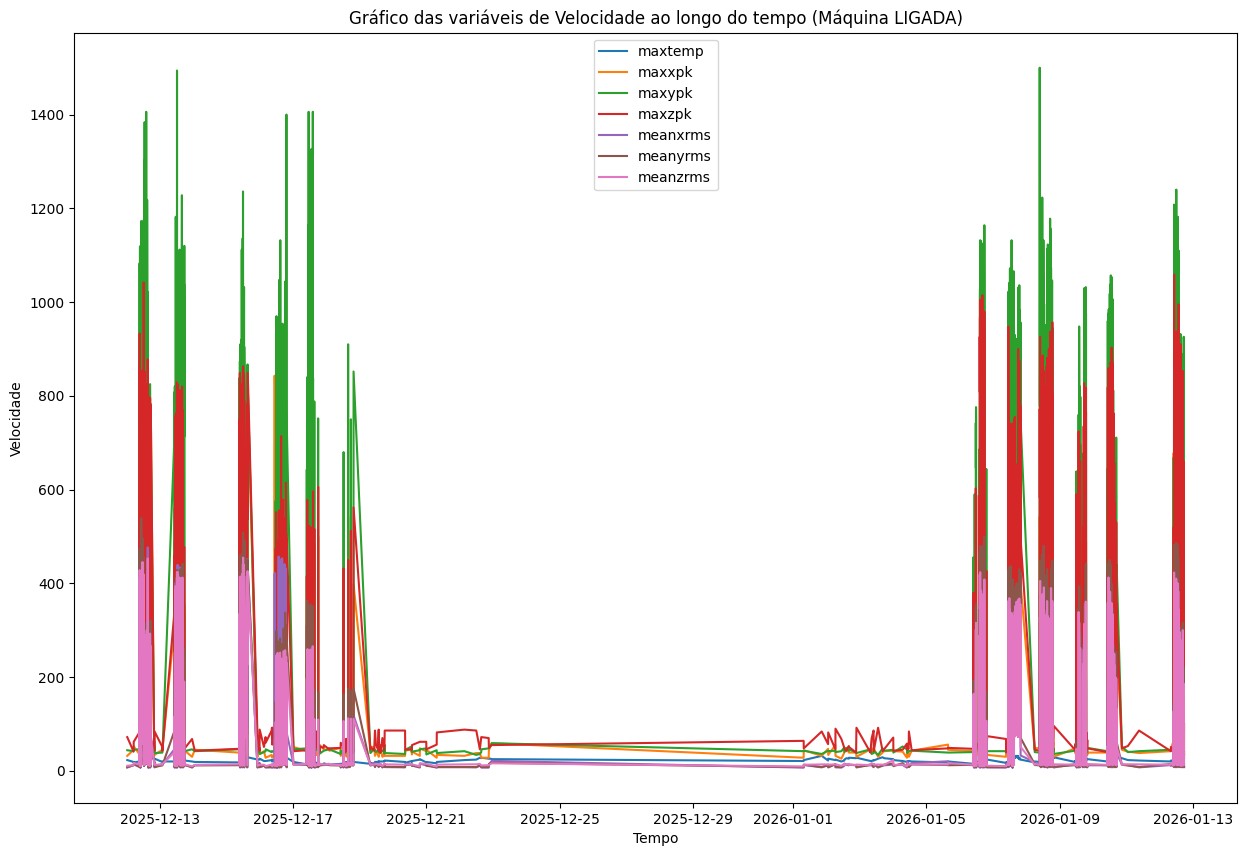

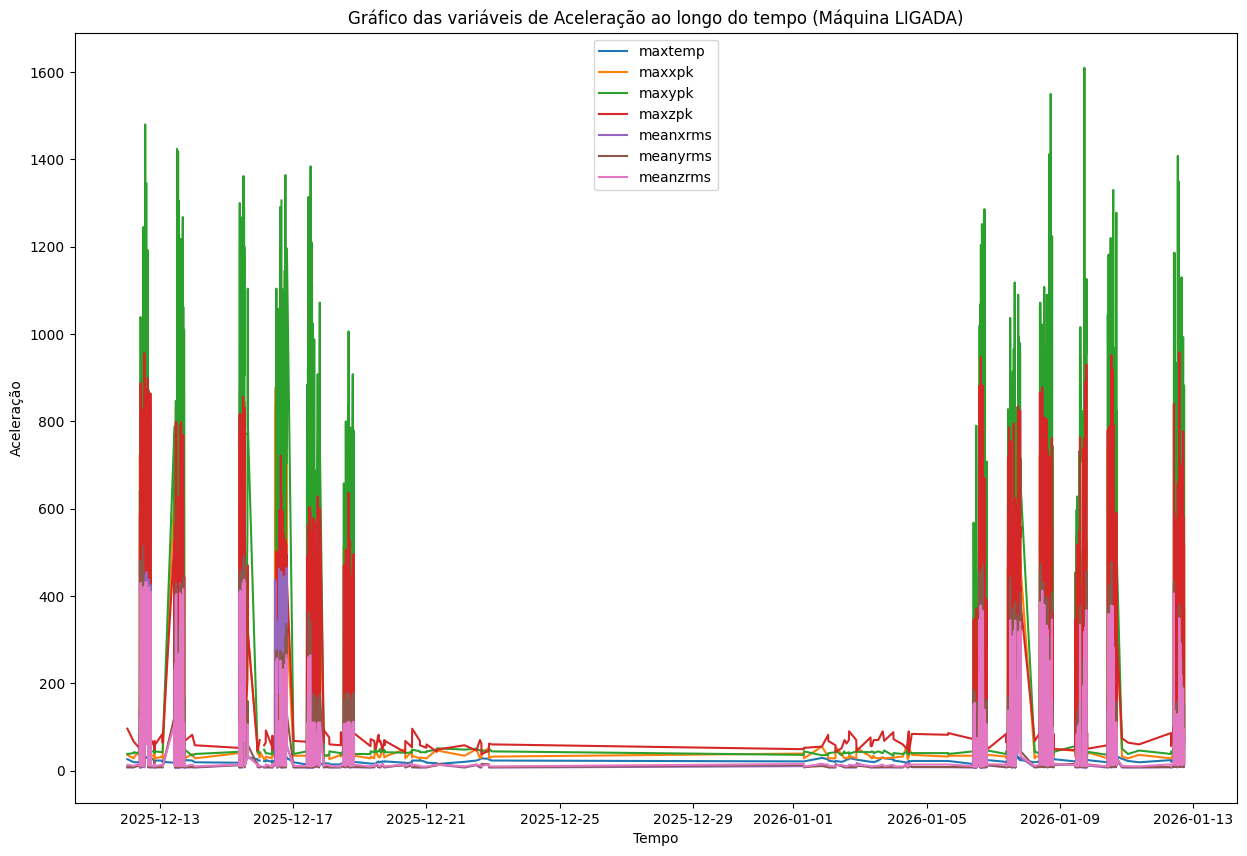

In [56]:
# Gráfico geral - Velocidade (máquina ligada)
plt.figure(figsize=(15, 10))
for col in df_vel_m3_on.columns:
    if col not in ['time', 'is_on']:
        plt.plot(df_vel_m3_on['time'], df_vel_m3_on[col], label=col)
plt.legend()
plt.title('Gráfico das variáveis de Velocidade ao longo do tempo (Máquina LIGADA)')
plt.xlabel('Tempo')
plt.ylabel('Velocidade')
plt.show()

# Gráfico geral - Aceleração (máquina ligada)
plt.figure(figsize=(15, 10))
for col in df_acc_m3_on.columns:
    if col not in ['time', 'is_on']:
        plt.plot(df_acc_m3_on['time'], df_acc_m3_on[col], label=col)
plt.legend()
plt.title('Gráfico das variáveis de Aceleração ao longo do tempo (Máquina LIGADA)')
plt.xlabel('Tempo')
plt.ylabel('Aceleração')
plt.show()

Exibindo os 100 primeiros registros da tabela:


,time,maxtemp,maxxpk,maxypk,maxzpk,meanxrms,meanyrms,meanzrms,is_on,y_suave
1108,2026-01-12 14:51:00,32.0,472.0,932.0,895.0,137.285721,287.285706,261.571442,True,66.704760
1109,2026-01-12 14:56:00,32.0,425.0,900.0,859.0,130.142853,248.714279,246.857147,True,114.214283
1110,2026-01-12 15:01:00,31.0,55.0,52.0,52.0,13.333333,12.833333,18.000000,True,114.980949
1111,2026-01-12 15:06:00,32.0,470.0,878.0,910.0,149.571426,299.714294,278.285706,True,172.209522
1112,2026-01-12 15:11:00,31.0,40.0,45.0,45.0,12.571428,15.000000,15.571428,True,172.709522
1113,2026-01-12 15:16:00,32.0,39.0,43.0,37.0,11.666667,15.500000,10.500000,True,118.352381
1114,2026-01-12 15:21:00,32.0,45.0,46.0,49.0,13.142858,14.428572,13.666667,True,71.495240
1115,2026-01-12 15:26:00,32.0,44.0,43.0,41.0,13.333333,12.666667,13.200000,True,71.461907
1116,2026-01-12 15:31:00,32.0,386.0,890.0,628.0,114.142860,248.428574,208.571426,True,61.204762
1117,2026-01-12 15:36:00,32.0,47.0,52.0,48.0,12.857142,13.142858,16.428572,True,60.833334


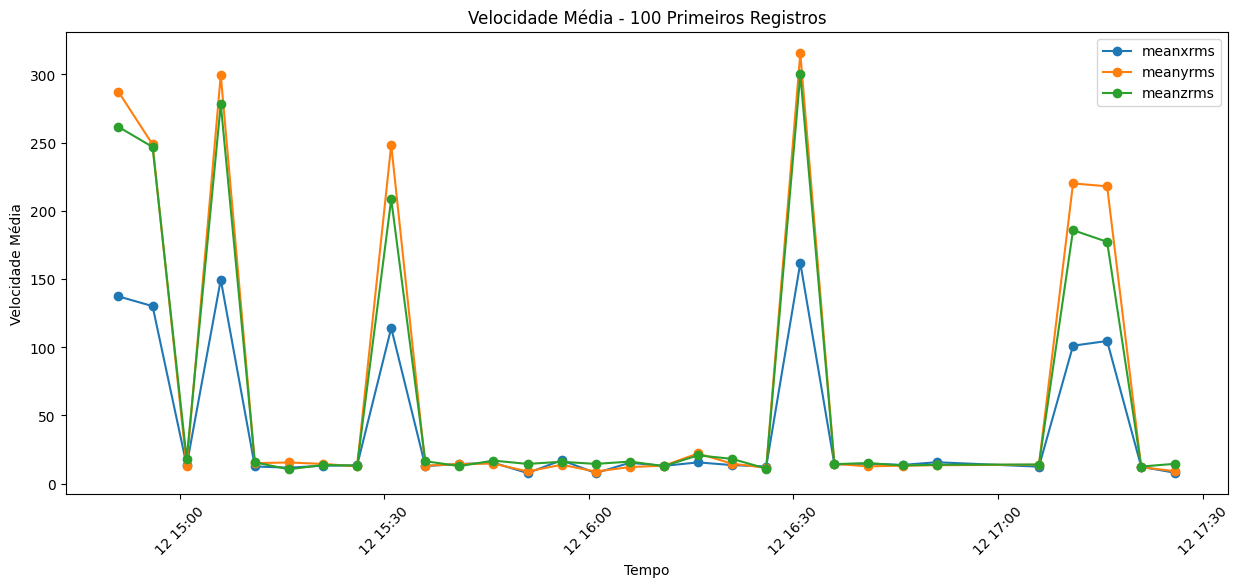

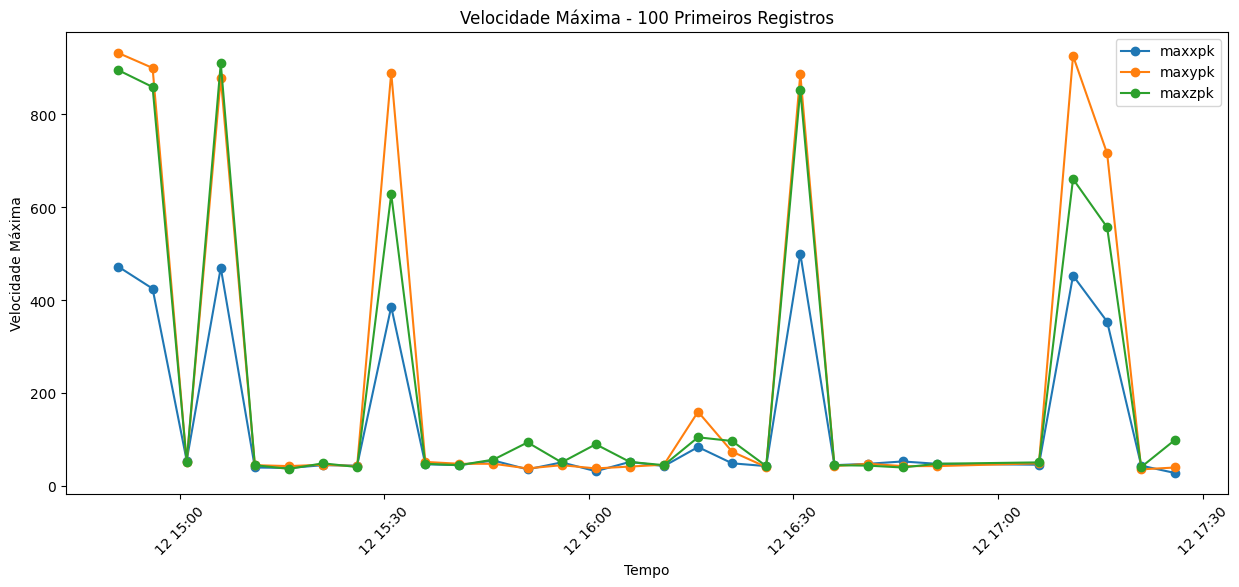

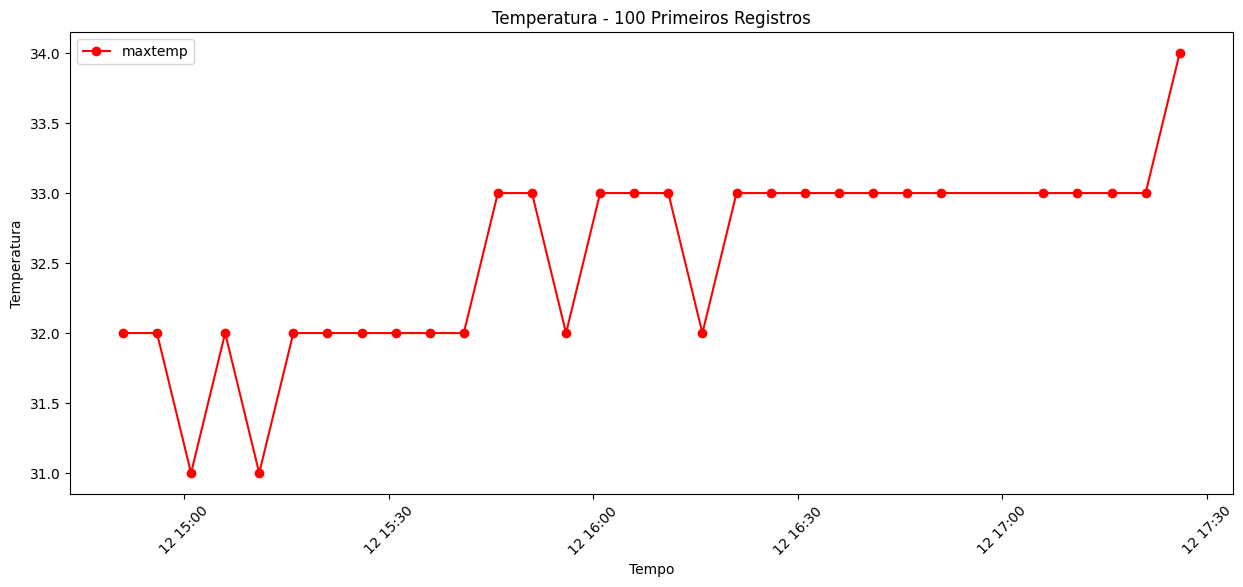

In [71]:
# Criando um DataFrame auxiliar apenas com os 100 primeiros registros
df_100 = df_vel_m3_on.tail(30)

# Opcional: printar a tabela dos 100 primeiros no console/notebook
print("Exibindo os 100 primeiros registros da tabela:")
display(df_100) 

# --- Gráficos limitados aos 100 primeiros dados ---

# 1. Gráfico de Velocidade Média
plt.figure(figsize=(15, 6)) # Diminuí um pouco a altura para facilitar a visualização de poucos dados
for col in df_100.columns:
    if 'mean' in col:
        # Usamos df_100 aqui para pegar só os 100 primeiros
        plt.plot(df_100['time'], df_100[col], label=col, marker='o') # Adicionei marker='o' para ver os pontos individuais
plt.legend()
plt.title('Velocidade Média - 100 Primeiros Registros')
plt.xlabel('Tempo')
plt.ylabel('Velocidade Média')
plt.xticks(rotation=45) # Inclina a data para não sobrepor
plt.show()

# 2. Gráfico de Velocidade Máxima
plt.figure(figsize=(15, 6))
for col in df_100.columns:
    if 'max' in col and 'maxtemp' not in col:
        plt.plot(df_100['time'], df_100[col], label=col, marker='o')
plt.legend()
plt.title('Velocidade Máxima - 100 Primeiros Registros')
plt.xlabel('Tempo')
plt.ylabel('Velocidade Máxima')
plt.xticks(rotation=45)
plt.show()

# 3. Gráfico de Temperatura
plt.figure(figsize=(15, 6))
for col in df_100.columns:
    if 'maxtemp' in col:
        plt.plot(df_100['time'], df_100[col], label=col, marker='o', color='red')
plt.legend()
plt.title('Temperatura - 100 Primeiros Registros')
plt.xlabel('Tempo')
plt.ylabel('Temperatura')
plt.xticks(rotation=45)
plt.show()

# Exportar dados pré-processados
Para a Parte 2 ficar mais leve/legível, salvamos aqui os DataFrames pré-processados.
Arquivo gerado: `m3_preprocess_cache.pkl` (na pasta Diadema).

In [58]:
from pathlib import Path
import pandas as pd

# Requer: diadema_dir
cache_path = (diadema_dir / "m3_preprocess_cache.pkl") if 'diadema_dir' in globals() else Path.cwd() / "m3_preprocess_cache.pkl"

# Se você não rodou a separação ligada/desligada, mantém compatibilidade
if "df_vel_m3_all" not in globals():
    df_vel_m3_all = df_vel_m3_group.copy()
    df_acc_m3_all = df_acc_m3_group.copy()
    df_vel_m3_all["is_on"] = True
    df_acc_m3_all["is_on"] = True
    df_vel_m3_on = df_vel_m3_group.copy()
    df_acc_m3_on = df_acc_m3_group.copy()
    df_vel_m3_off = df_vel_m3_group.iloc[0:0].copy()
    df_acc_m3_off = df_acc_m3_group.iloc[0:0].copy()
    split_params = {}
else:
    split_params = {k: v for k, v in globals().get("split_res", {}).items() if k not in {"df_vel_all","df_acc_all","df_vel_on","df_vel_off","df_acc_on","df_acc_off"}}

pd.to_pickle(
    {
        "df_vel_m3_group": df_vel_m3_group,
        "df_acc_m3_group": df_acc_m3_group,
        "df_vel_m3_all": df_vel_m3_all,
        "df_acc_m3_all": df_acc_m3_all,
        "df_vel_m3_on": df_vel_m3_on,
        "df_acc_m3_on": df_acc_m3_on,
        "df_vel_m3_off": df_vel_m3_off,
        "df_acc_m3_off": df_acc_m3_off,
        "split_params": split_params,
    },
    cache_path,
)
print(f"Cache salvo em: {cache_path}")
print(f"Vel: total={len(df_vel_m3_all)}, on={len(df_vel_m3_on)}, off={len(df_vel_m3_off)}")
print(f"Acc: total={len(df_acc_m3_all)}, on={len(df_acc_m3_on)}, off={len(df_acc_m3_off)}")

Cache salvo em: C:\Users\617984\OneDrive - parkercorp\Vibration data\Diadema\m3_preprocess_cache.pkl
Vel: total=6585, on=1138, off=5447
Acc: total=6585, on=1138, off=5447
